# 00 — Data Preprocessing (TabReD-faithful, RAM-aware)

Loads the raw Kaggle *Home Credit — Credit Risk Model Stability* train files
and produces a numeric feature matrix that follows TabReD's
`homecredit-default.py` recipe (Rubachev et al., ICLR 2025), with two
modifications: an early-subsample RAM optimisation and a single ordinal-
encoder fit on the subsample.

## TabReD recipe (faithfully reproduced)

1. Load the base table, two static (depth-0) tables, and ten relational
   feature tables (depth-1 + depth-2).
2. Aggregate every non-static table to one row per `case_id` with a single
   uniform recipe:
   - `P` / `A` / `T` / `L` columns → `max`, `min`, `mean`, `std`
   - `M` columns → `last`, `n_unique`, `first`
   - `D` columns → `max`, `min`, `mean`, `std`
3. Left-join all aggregates onto the base table.
4. Convert every remaining `D`-suffixed column to *days since* `date_decision`.
5. Drop columns by hard rules: more than 95% nulls, single distinct value,
   string columns with more than 50 distinct values; plus the hard-coded
   leftovers `min_sex_738L`, `MONTH`, `WEEK_NUM`.
6. Define two binary features (`isbidproduct_1095L`, `max_sex_738L == 'F'`),
   ordinal-encode the remaining string columns with `min_frequency = 1/100`.
7. Add three calendar features (`day_of_week`, `day_of_month`, `day_of_year`)
   derived from `date_decision`.

## Two adjustments

**Early subsample (RAM).** TabReD subsamples 25% of the rows *after*
preprocessing. We subsample *before* preprocessing, so each depth-1 / depth-2
table is filtered to the subsample case_ids before aggregation. Aggregations
are keyed on `case_id`, so each case_id's aggregated features are bit-for-bit
identical regardless of subsample order. The only side-effect is that
column-drop statistics and the ordinal-encoder fit see only the subsample;
for any reasonable `N_SUBSAMPLE` this is statistically indistinguishable
from TabReD's behaviour.

**Single encoder fit (mild leakage mitigation).** TabReD fits the ordinal
encoder on the entire dataset before subsampling. Because the rolling-
retraining methodology trains models on early time windows and evaluates
on later ones, this lets categorical encoding "see the future" via the
`min_frequency` threshold. We instead fit the encoder once on the subsample
data, treating it as a fixed pre-experiment design choice — the same
encoding is used in every rolling window. This is a strictly weaker form
of the same step TabReD performs and matches what a deployed system can
do: lock in the encoding from a snapshot of historical data and apply the
same transform to all later batches.

## RAM-aware engineering (preserved from the project's earlier preprocessing)

- Each depth-1 / depth-2 table is filtered to the subsample case_ids on
  read, so the in-memory intermediate is small.
- The two largest depth-2 tables are processed in case_id chunks of 50 000.
- Per-table caches let repeated runs skip the heavy aggregation.
- Heavy intermediates are `del`-eted and `gc.collect()`-ed between steps.

## Output contract (preserved for notebooks 01–04)

| File | Contents |
|------|----------|
| `data/processed/X.parquet` | Feature matrix, fully numeric (`float32`), no NaN |
| `data/processed/Y.npy` | Binary target (`int8`), 1 = default |
| `data/processed/meta.parquet` | `case_id`, `date_decision`, `MONTH`, `WEEK_NUM` |
| `data/processed/feature_names.json` | Keys `all`, `num`, `bin`, `cat` |

Column order in `X` is `[num | cat | bin]`. Downstream notebooks treat
`num ∪ cat` as the numeric pathway and `bin` as the binary pathway.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Wipe stale caches and downstream artefacts so a re-run is reproducible.
from pathlib import Path
import shutil

WORKSPACE = Path('/content/drive/MyDrive/HomeCredit_workspace')
CACHE_DIR = WORKSPACE / 'data' / 'cache'
PROC_DIR  = WORKSPACE / 'data' / 'processed'

for f in CACHE_DIR.glob('d*_aggregated*.parquet'):
    f.unlink(); print(f'Removed: cache/{f.name}')
for f in [CACHE_DIR / 'd0_merged.parquet',
          CACHE_DIR / 'tabred_aggregated.parquet']:
    if f.exists():
        f.unlink(); print(f'Removed: cache/{f.name}')

for f in ['X.parquet', 'X_num_raw.parquet', 'X_cat_encoded.parquet',
          'X_bin.parquet', 'Y.npy', 'meta.parquet', 'feature_names.json',
          'date_distribution.png']:
    p = PROC_DIR / f
    if p.exists():
        p.unlink(); print(f'Removed: processed/{f}')

for sub in ['models', 'shap', 'lime', 'results', 'windows']:
    d = WORKSPACE / 'data' / sub
    if d.exists():
        shutil.rmtree(d); print(f'Removed: data/{sub}/')

print('\nReady for TabReD-faithful, RAM-aware run.')


Ready for TabReD-faithful, RAM-aware run.


## 1. Setup and parameters

In [3]:
import gc
import json
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
from sklearn.preprocessing import OrdinalEncoder
import matplotlib.pyplot as plt

# ── Paths ───────────────────────────────────────────────────────────
WORKSPACE = Path('/content/drive/MyDrive/HomeCredit_workspace')
RAW_DIR   = WORKSPACE / 'data' / 'raw'
CACHE_DIR = WORKSPACE / 'data' / 'cache'
PROC_DIR  = WORKSPACE / 'data' / 'processed'
for d in [RAW_DIR, CACHE_DIR, PROC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Locate the train directory (zip already extracted upstream).
candidates = list(RAW_DIR.rglob('train_base.parquet'))
assert candidates, f'train_base.parquet not found under {RAW_DIR}'
TRAIN_DIR = candidates[0].parent
print(f'TRAIN_DIR: {TRAIN_DIR}')

# ── Subsample size (adjustable) ─────────────────────────────────────
# TabReD's homecredit.py uses a 25% sample (~381,664 rows). Set this to
# the row count you want in the final feature matrix; None means 'use the
# full dataset, no subsampling' (NB: requires significant RAM).
N_SUBSAMPLE = 600_000
SUBSAMPLE_SEED = 0
print(f'N_SUBSAMPLE: {N_SUBSAMPLE!r}')
print(f'SUBSAMPLE_SEED: {SUBSAMPLE_SEED}')

TRAIN_DIR: /content/drive/MyDrive/HomeCredit_workspace/data/raw
N_SUBSAMPLE: 600000
SUBSAMPLE_SEED: 0


## 2. Helpers — TabReD's `set_table_dtypes` and `aggregate_features`

The dtype helper casts ID and date columns explicitly and downcasts numerics
to the smallest type that fits the data range. The aggregation helper
applies the single uniform recipe to every non-static table.

| Suffix | Aggregations |
|--------|--------------|
| `P`, `A`, `T`, `L` | `max`, `min`, `mean`, `std` |
| `M` | `last`, `n_unique`, `first` |
| `D` | `max`, `min`, `mean`, `std` |

In [4]:
def set_table_dtypes(df: pl.LazyFrame) -> pl.LazyFrame:
    """Cast ID columns to Int32, date-like columns (suffix 'D' or named
    'date_decision') to Date, and downcast numerics to the smallest type
    that fits their min/max range. Faithful to TabReD's homecredit.py.
    """
    for col in df.collect_schema().names():
        if col in ('case_id', 'WEEK_NUM', 'num_group1', 'num_group2'):
            df = df.with_columns(pl.col(col).cast(pl.Int32))
        elif col == 'date_decision' or col[-1] == 'D':
            df = df.with_columns(pl.col(col).cast(pl.Date))

    int_types   = (pl.Int8, pl.Int16, pl.Int32, pl.Int64)
    float_types = (pl.Float32, pl.Float64)
    table_min = df.select(pl.col('*').min()).collect(streaming=True)
    table_max = df.select(pl.col('*').max()).collect(streaming=True)

    for col, col_type in df.collect_schema().items():
        c_min = table_min[col].item()
        c_max = table_max[col].item()
        if c_min is None or c_max is None:
            continue
        if col_type in int_types:
            for cand_type, np_info in [(pl.Int8, np.iinfo(np.int8)),
                                        (pl.Int16, np.iinfo(np.int16)),
                                        (pl.Int32, np.iinfo(np.int32)),
                                        (pl.Int64, np.iinfo(np.int64))]:
                if c_min > np_info.min and c_max < np_info.max:
                    df = df.with_columns(pl.col(col).cast(cand_type))
                    break
        elif col_type in float_types:
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df = df.with_columns(pl.col(col).cast(pl.Float32))
    return df


def read_tables_lazy(table_paths) -> pl.LazyFrame:
    """Lazy-concatenate parquet files matching a glob."""
    table_paths = list(table_paths)
    assert table_paths, 'No parquet files matched.'
    return pl.concat([
        pl.scan_parquet(p, low_memory=True, rechunk=True) for p in table_paths
    ], how='vertical_relaxed')


def aggregate_features(df: pl.LazyFrame) -> pl.LazyFrame:
    """TabReD's uniform aggregation recipe: one row per case_id.

    Numeric (P/A/T/L) and date (D) columns get max/min/mean/std; masked
    categorical (M) columns get last/n_unique/first. Sorted by num_group1
    before group-by so 'last' and 'first' are deterministic.

    The aggregation is keyed on case_id, which uniquely identifies one
    loan application with one date_decision. No aggregation crosses
    case_ids, so the per-case_id result is bit-for-bit identical whether
    we subsample case_ids before or after this step.

    Implementation note: D-suffixed columns are cast to Int32 (days since
    epoch) before aggregation, because polars no longer supports `std` on
    the Date dtype. This preserves TabReD's intended semantics exactly:
    the integer count of days is an ordinal representation of the date,
    and the subsequent "days since date_decision" subtraction yields the
    same numeric result whether performed on Dates or on day-counts.
    """
    schema = df.collect_schema()
    cols = schema.names()

    # Cast D-suffixed columns to Int32 (days since epoch) so std() works.
    # We exclude 'date_decision' itself: it is part of the base table and
    # must remain a Date there.
    date_cols_to_cast = [c for c in cols
                         if c.endswith('D') and c != 'date_decision'
                         and schema[c] == pl.Date]
    if date_cols_to_cast:
        df = df.with_columns([
            pl.col(c).cast(pl.Date).cast(pl.Int32, strict=False)
            for c in date_cols_to_cast
        ])

    exprs = []
    for col in cols:
        if col[-1] in ('P', 'A', 'T', 'L'):
            exprs.extend([
                pl.col(col).max().alias(f'max_{col}'),
                pl.col(col).min().alias(f'min_{col}'),
                pl.col(col).mean().alias(f'mean_{col}'),
                pl.col(col).std().alias(f'std_{col}'),
            ])
    for col in cols:
        if col[-1] == 'M':
            exprs.extend([
                pl.col(col).last().alias(f'last_{col}'),
                pl.col(col).n_unique().alias(f'n_unique_{col}'),
                pl.col(col).first().alias(f'first_{col}'),
            ])
    for col in cols:
        if col[-1] == 'D':
            # Now Int32 (days since epoch) — std works.
            exprs.extend([
                pl.col(col).max().alias(f'max_{col}'),
                pl.col(col).min().alias(f'min_{col}'),
                pl.col(col).mean().alias(f'mean_{col}'),
                pl.col(col).std().alias(f'std_{col}'),
            ])
    return df.sort('num_group1').group_by('case_id').agg(exprs)


print('Helpers defined.')

Helpers defined.


## 3. Load base table and subsample case_ids

We load `train_base` and pick `N_SUBSAMPLE` case_ids uniformly at random.
All downstream steps work only on these case_ids. This is the key RAM
optimisation: each depth-1 / depth-2 table is filtered down to the
subsample before aggregation, so the in-memory groupby never grows past
the subsample size.

In [5]:
# Load base table — one row per case_id, with target and date_decision.
base = pl.read_parquet(TRAIN_DIR / 'train_base.parquet')
base = base.with_columns([
    pl.col('case_id').cast(pl.Int64),
    pl.col('date_decision').cast(pl.Date),
    pl.col('target').cast(pl.Int8),
])
print(f'train_base raw shape: {base.shape}')

# Subsample case_ids.
if N_SUBSAMPLE is not None and base.shape[0] > N_SUBSAMPLE:
    base = base.sample(n=N_SUBSAMPLE, seed=SUBSAMPLE_SEED, shuffle=True)
    print(f'Subsampled to {base.shape[0]:,} case_ids.')
else:
    print(f'Using full base table: {base.shape[0]:,} case_ids.')

base = base.sort('date_decision')
print(f'Date range: {base["date_decision"].min()} → {base["date_decision"].max()}')

# Build the case_id filter set used everywhere downstream.
case_id_set = set(base['case_id'].to_list())
print(f'case_id_set size: {len(case_id_set):,}')

train_base raw shape: (1526659, 5)
Subsampled to 600,000 case_ids.
Date range: 2019-01-01 → 2020-10-05
case_id_set size: 600,000


## 4. Static (depth-0) tables — direct join

The two static tables already have one row per `case_id`, so they join
directly without aggregation. We filter each table to the subsample
case_ids before joining.

In [6]:
d0_cache = CACHE_DIR / 'd0_merged.parquet'

if d0_cache.exists():
    print('Loading cached depth-0 merge ...')
    d0 = pl.read_parquet(d0_cache)
    print(f'Loaded: {d0.shape}')
else:
    static_0  = read_tables_lazy(TRAIN_DIR.glob('train_static_0_*.parquet')).pipe(set_table_dtypes)
    static_cb = read_tables_lazy(TRAIN_DIR.glob('train_static_cb_0.parquet')).pipe(set_table_dtypes)

    # Filter to subsample, then materialise — small enough to fit in RAM easily.
    static_0  = static_0.filter(pl.col('case_id').is_in(case_id_set)).collect(streaming=True)
    static_cb = static_cb.filter(pl.col('case_id').is_in(case_id_set)).collect(streaming=True)
    print(f'static_0:    {static_0.shape}')
    print(f'static_cb_0: {static_cb.shape}')

    d0 = (
        base
        .join(static_0,  on='case_id', how='left')
        .join(static_cb, on='case_id', how='left', suffix='_cb')
    )
    print(f'Merged depth-0: {d0.shape}')

    d0.write_parquet(d0_cache)
    print(f'Cached to {d0_cache}')

    del static_0, static_cb
    gc.collect()

/tmp/ipykernel_7035/1567881244.py:14: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  table_min = df.select(pl.col('*').min()).collect(streaming=True)
/tmp/ipykernel_7035/1567881244.py:15: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  table_max = df.select(pl.col('*').max()).collect(streaming=True)
/tmp/ipykernel_7035/264005565.py:12: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  static_0  = static_0.filter(pl.col('case_id').is_in(case_id_set)).collect(streaming=True)
/tmp/ipykernel_7035/264005565.py:13: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  static_cb = static_cb.filter(pl.col('case_id').is_in(case_id_set)).collect(streaming=True)


static_0:    (600000, 168)
static_cb_0: (589540, 53)
Merged depth-0: (600000, 224)
Cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/d0_merged.parquet


## 5. Aggregate the relational tables (TabReD recipe)

Every relational table is reduced to one row per `case_id` via TabReD's
single uniform recipe (`aggregate_features`). For the largest depth-2
tables we process the case_ids in chunks of 50 000 to bound peak memory
usage; the per-chunk results are concatenated into a small per-case_id
frame at the end.

In [7]:
# Tables to aggregate, in TabReD's order.
RELATIONAL_GLOBS = [
    ('applprev_1',     'train_applprev_1_*.parquet',           False),
    ('tax_a_1',        'train_tax_registry_a_1.parquet',       False),
    ('tax_b_1',        'train_tax_registry_b_1.parquet',       False),
    ('tax_c_1',        'train_tax_registry_c_1.parquet',       False),
    ('credit_a_1',     'train_credit_bureau_a_1_*.parquet',    False),
    ('credit_b_1',     'train_credit_bureau_b_1.parquet',      False),
    ('other_1',        'train_other_1.parquet',                False),
    ('person_1',       'train_person_1.parquet',               False),
    ('deposit_1',      'train_deposit_1.parquet',              False),
    ('debitcard_1',    'train_debitcard_1.parquet',            False),
    # Depth-2: chunked.
    ('credit_a_2',     'train_credit_bureau_a_2_*.parquet',    True),
    ('credit_b_2',     'train_credit_bureau_b_2.parquet',      True),
]

CHUNK_SIZE = 50_000


def aggregate_table_one_shot(glob_pattern: str) -> pl.DataFrame:
    """Filter + dtype + aggregate, all in one polars pipeline."""
    paths = list(TRAIN_DIR.glob(glob_pattern))
    if not paths:
        return None
    lf = read_tables_lazy(paths)
    lf = lf.filter(pl.col('case_id').is_in(case_id_set)).pipe(set_table_dtypes)
    out = aggregate_features(lf).collect(streaming=True)
    return out


def aggregate_table_chunked(glob_pattern: str, chunk_size: int = CHUNK_SIZE) -> pl.DataFrame:
    """Aggregate a (large) table in case_id chunks to bound peak memory.

    Each chunk reads the parquet files lazily, filters to that chunk's
    case_ids, applies set_table_dtypes + aggregate_features, then collects.
    Per-chunk results have one row per case_id in the chunk and are
    concatenated at the end — small enough to vertical_relaxed without
    blowing memory.
    """
    paths = list(TRAIN_DIR.glob(glob_pattern))
    if not paths:
        return None

    case_id_list = sorted(case_id_set)
    n_chunks = (len(case_id_list) + chunk_size - 1) // chunk_size
    print(f'    chunked: {n_chunks} chunks of ~{chunk_size:,} case_ids each')

    chunk_results = []
    for chunk_idx in range(n_chunks):
        start = chunk_idx * chunk_size
        end   = min(start + chunk_size, len(case_id_list))
        chunk_ids = set(case_id_list[start:end])

        lf = read_tables_lazy(paths)
        lf = lf.filter(pl.col('case_id').is_in(chunk_ids)).pipe(set_table_dtypes)
        out = aggregate_features(lf).collect(streaming=True)
        chunk_results.append(out)

        if (chunk_idx + 1) % 2 == 0 or chunk_idx == n_chunks - 1:
            print(f'    chunk {chunk_idx + 1}/{n_chunks} done '
                  f'(rows so far: {sum(c.shape[0] for c in chunk_results):,})')

    if not chunk_results:
        return None
    return pl.concat(chunk_results, how='vertical_relaxed')


# Loop over the tables, with per-table caching.
aggregated_frames = []
for prefix, glob, is_chunked in RELATIONAL_GLOBS:
    cache_path = CACHE_DIR / f'agg_{prefix}.parquet'

    if cache_path.exists():
        print(f'[{prefix}] loading cached aggregate ...')
        agg = pl.read_parquet(cache_path)
        print(f'  shape: {agg.shape}')
    else:
        print(f'[{prefix}] aggregating ({"chunked" if is_chunked else "one-shot"}) ...')
        if is_chunked:
            agg = aggregate_table_chunked(glob)
        else:
            agg = aggregate_table_one_shot(glob)
        if agg is None:
            print(f'  WARNING: no files matched {glob} — skipping.')
            continue
        # Prefix every non-key column with the table name to avoid suffix-collision after join.
        agg = agg.rename({c: f'{prefix}_{c}' for c in agg.columns if c != 'case_id'})
        print(f'  shape: {agg.shape}')
        agg.write_parquet(cache_path)
        print(f'  cached to {cache_path}')
        gc.collect()

    aggregated_frames.append(agg)

print(f'\nTotal aggregated tables: {len(aggregated_frames)}')

[applprev_1] aggregating (one-shot) ...


/tmp/ipykernel_7035/1567881244.py:14: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  table_min = df.select(pl.col('*').min()).collect(streaming=True)
/tmp/ipykernel_7035/1567881244.py:15: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  table_max = df.select(pl.col('*').max()).collect(streaming=True)
/tmp/ipykernel_7035/1894159923.py:28: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  out = aggregate_features(lf).collect(streaming=True)


  shape: (479792, 150)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_applprev_1.parquet
[tax_a_1] aggregating (one-shot) ...
  shape: (180120, 12)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_tax_a_1.parquet
[tax_b_1] aggregating (one-shot) ...
  shape: (59082, 12)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_tax_b_1.parquet
[tax_c_1] aggregating (one-shot) ...
  shape: (189142, 12)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_tax_c_1.parquet
[credit_a_1] aggregating (one-shot) ...
  shape: (544583, 298)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_credit_a_1.parquet
[credit_b_1] aggregating (one-shot) ...
  shape: (14483, 164)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_credit_b_1.parquet
[other_1] aggregating (one-shot) ...
  shape: (20029, 21)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_other_1.parquet


/tmp/ipykernel_7035/1894159923.py:57: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  out = aggregate_features(lf).collect(streaming=True)


    chunk 2/12 done (rows so far: 85,046)
    chunk 4/12 done (rows so far: 165,816)
    chunk 6/12 done (rows so far: 247,938)
    chunk 8/12 done (rows so far: 346,302)
    chunk 10/12 done (rows so far: 446,001)
    chunk 12/12 done (rows so far: 534,843)
  shape: (534843, 59)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_credit_a_2.parquet
[credit_b_2] aggregating (chunked) ...
    chunked: 12 chunks of ~50,000 case_ids each
    chunk 2/12 done (rows so far: 2,852)
    chunk 4/12 done (rows so far: 5,028)
    chunk 6/12 done (rows so far: 6,998)
    chunk 8/12 done (rows so far: 9,222)
    chunk 10/12 done (rows so far: 12,489)
    chunk 12/12 done (rows so far: 14,458)
  shape: (14458, 13)
  cached to /content/drive/MyDrive/HomeCredit_workspace/data/cache/agg_credit_b_2.parquet

Total aggregated tables: 12


## 6. Assemble feature matrix and convert dates

Outer-join all aggregated frames onto each other on `case_id`, then
left-join the result onto the depth-0 frame. Every remaining `D`-suffixed
column is then converted to *days since `date_decision`*.

In [8]:
# Outer-join aggregated frames first (all small, ~one row per case_id).
print('Joining aggregated frames ...')
d1 = aggregated_frames[0]
for i, other in enumerate(aggregated_frames[1:], start=2):
    d1 = d1.join(other, on='case_id', how='full', coalesce=True)
    print(f'  after join {i}: {d1.shape}')
    gc.collect()

# Join onto the depth-0 frame.
print('\nJoining d0 + d1 ...')
data = d0.join(d1, on='case_id', how='left')
print(f'Full merged frame: {data.shape}')

del d0, d1, aggregated_frames
gc.collect()

# TabReD's date conversion: every D-suffixed column → days since date_decision.
# Implementation note: depth-1 / depth-2 D-columns were already cast to Int32
# (days since epoch) inside aggregate_features so that std() worked. Here we
# subtract date_decision's days-since-epoch from each of those Int32 columns
# to obtain days-since-date_decision, which is numerically identical to
# TabReD's Date - Date → Duration → total_days() conversion.
# Any D-suffixed column that is still pl.Date (e.g. directly from a depth-0
# static table) is converted via the original Date - Date subtraction.
print('\nConverting D-columns to days since date_decision ...')
date_decision_int = pl.col('date_decision').cast(pl.Int32)

# Build the conversion expressions per column based on its current dtype.
schema = data.schema
conversion_exprs = []
n_int_d, n_date_d = 0, 0
for c, dt in schema.items():
    if not c.endswith('D') or c == 'date_decision':
        continue
    if dt == pl.Date:
        conversion_exprs.append(
            (pl.col(c) - pl.col('date_decision')).dt.total_days().cast(pl.Float32).alias(c)
        )
        n_date_d += 1
    elif dt in (pl.Int8, pl.Int16, pl.Int32, pl.Int64,
                pl.Float32, pl.Float64):
        conversion_exprs.append(
            (pl.col(c).cast(pl.Float32) - date_decision_int.cast(pl.Float32)).alias(c)
        )
        n_int_d += 1
    # else: leave untouched

if conversion_exprs:
    data = data.with_columns(conversion_exprs)
print(f'  converted {n_int_d} Int D-columns and {n_date_d} Date D-columns')

Joining aggregated frames ...
  after join 2: (516488, 161)
  after join 3: (525128, 172)
  after join 4: (561694, 183)
  after join 5: (587210, 480)
  after join 6: (587298, 643)
  after join 7: (587317, 663)
  after join 8: (600000, 795)
  after join 9: (600000, 807)
  after join 10: (600000, 823)
  after join 11: (600000, 881)
  after join 12: (600000, 893)

Joining d0 + d1 ...
Full merged frame: (600000, 1116)

Converting D-columns to days since date_decision ...
  converted 128 Int D-columns and 24 Date D-columns


## 7. Drop redundant columns (TabReD's rules, on the subsample)

TabReD's rules: more than 95% nulls, single distinct value, or a string
column with more than 50 distinct values. We compute these statistics on
the (subsampled) data we have here. The hard-coded leftovers
`min_sex_738L`, `MONTH`, `WEEK_NUM` are also dropped from the feature
matrix — but `MONTH` and `WEEK_NUM` are first preserved into `meta`, since
notebook 01 needs them.

In [9]:
# Preserve meta columns BEFORE the drop step.
meta_pre = data.select(['case_id', 'date_decision', 'MONTH', 'WEEK_NUM']).to_pandas()
meta_pre['date_decision'] = pd.to_datetime(meta_pre['date_decision'])

# TabReD's drop rules.
print('Computing drop statistics ...')
many_nulls = data.select(pl.col('*').is_null().mean().gt(0.95))
n_unique   = data.select(pl.col('*').drop_nulls().n_unique())

drop_cols = [
    c for c, dtype in data.schema.items()
    if (many_nulls[c].item() or
        n_unique[c].item() == 1 or
        (dtype == pl.String and n_unique[c].item() > 50))
]

# Defensive: never drop the columns we structurally need.
must_keep = {'case_id', 'date_decision', 'target'}
drop_cols = [c for c in drop_cols if c not in must_keep]
print(f'Dropping {len(drop_cols)} columns by TabReD\'s rules')

data = data.drop(drop_cols)

# TabReD's hard-coded leftovers.
leftover_drops = [c for c in ['min_sex_738L', 'MONTH', 'WEEK_NUM'] if c in data.columns]
if leftover_drops:
    data = data.drop(leftover_drops)
    print(f'Dropped leftovers: {leftover_drops}')
print(f'After all drops: {data.shape}')

Computing drop statistics ...
Dropping 393 columns by TabReD's rules
Dropped leftovers: ['MONTH', 'WEEK_NUM']
After all drops: (600000, 721)


## 8. Column types and binary indicators

TabReD partitions surviving columns into three groups:

- **`bin`** — `isbidproduct_1095L` and a derived flag `max_sex_738L_eq_F`.
- **`cat`** — every remaining `String`-typed column.
- **`num`** — every remaining numeric / boolean column.

In [10]:
# Materialise the boolean flag as a real column so the partition is uniform.
# The aggregated person table produces 'last_sex_738L', 'first_sex_738L', etc.
# TabReD's homecredit.py specifically uses 'max_sex_738L', which under our
# table-name prefix becomes 'person_1_max_sex_738L'.
sex_candidates = [c for c in data.columns if c.endswith('max_sex_738L')]
if sex_candidates:
    src = sex_candidates[0]
    data = data.with_columns(pl.col(src).eq('F').cast(pl.Boolean).alias('max_sex_738L_eq_F'))
    bin_names = []
    if 'isbidproduct_1095L' in data.columns:
        bin_names.append('isbidproduct_1095L')
    bin_names.append('max_sex_738L_eq_F')
else:
    bin_names = [c for c in ['isbidproduct_1095L'] if c in data.columns]

print(f'Binary indicators: {bin_names}')

# Categorical columns = strings that are not binaries / ids / target / sex-source.
exclude = set(bin_names) | {'target', 'case_id', 'date_decision'} | set(sex_candidates)
cat_cols = [c for c, dtype in data.schema.items()
            if c not in exclude and dtype == pl.String]

# Numeric columns = numerics + bools, excluding binaries / ids / target / sex-source.
num_cols = [c for c, dtype in data.schema.items()
            if c not in exclude and
               dtype in (pl.Float32, pl.Float64, pl.UInt32, pl.Int8, pl.Int16,
                         pl.Int32, pl.Int64, pl.Boolean)]

print(f'num: {len(num_cols)},  cat: {len(cat_cols)},  bin: {len(bin_names)}')

Binary indicators: ['isbidproduct_1095L', 'max_sex_738L_eq_F']
num: 632,  cat: 84,  bin: 2


## 9. Ordinal encoding — single fit on the subsample

The encoder is fit once on the entire subsample (matching TabReD's recipe
of `min_frequency = 1/100`) and applied to every row. It is *not* re-fit
per rolling window. Notes on its role in the rolling-retraining
methodology:

- The encoding is locked in once and used identically by every model
  trained in any rolling window. This is the same role a feature schema
  has in a deployed system.
- `min_frequency` therefore reflects the average behaviour of categorical
  values in the subsample. A category that is rare overall but common in
  one specific time window will still collapse into the rare bucket; this
  is a documented limitation of any pre-experiment encoding choice and is
  weaker than TabReD's full-dataset fit before subsampling.

In [11]:
# Convert to pandas for sklearn compatibility.
data_pd = data.to_pandas()
data_pd['date_decision'] = pd.to_datetime(data_pd['date_decision'])
print(f'pandas frame: {data_pd.shape}, '
      f'mem={data_pd.memory_usage(deep=True).sum()/1e9:.2f} GB')

# Single fit on the full subsample.
encoder = OrdinalEncoder(
    min_frequency=1/100,
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    encoded_missing_value=-2,
)
print(f'Fitting OrdinalEncoder on {len(data_pd):,} rows ...')
encoded = encoder.fit_transform(data_pd[cat_cols].to_numpy())
data_pd[cat_cols] = encoded

n_missing = (encoded == -2).sum()
n_total   = encoded.size
print(f'  missing (NaN): {n_missing:,}  ({n_missing/n_total:.2%})')
del data
gc.collect()

pandas frame: (600000, 722), mem=4.26 GB
Fitting OrdinalEncoder on 600,000 rows ...
  missing (NaN): 0  (0.00%)


0

## 10. Calendar features and final sort

Three calendar features are derived from each row's own `date_decision`,
matching TabReD's recipe. The final dataframe is sorted by
`date_decision`, which gives the canonical chronological ordering used
by notebook 01.

In [12]:
data_pd['day_of_week']  = data_pd['date_decision'].dt.weekday + 1   # 1..7
data_pd['day_of_month'] = data_pd['date_decision'].dt.day
data_pd['day_of_year']  = data_pd['date_decision'].dt.dayofyear
calendar_cols = ['day_of_week', 'day_of_month', 'day_of_year']

data_pd = data_pd.sort_values('date_decision').reset_index(drop=True)
print(f'After calendar features and sort: {data_pd.shape}')
print(f'Date range: {data_pd["date_decision"].min()} → '
      f'{data_pd["date_decision"].max()}')

After calendar features and sort: (600000, 725)
Date range: 2019-01-01 00:00:00 → 2020-10-05 00:00:00


## 11. Assemble outputs in the downstream contract

Materialise three blocks (`X_num`, `X_cat`, `X_bin`), concatenate them
in canonical order `[num | cat | bin]`, and fill remaining NaN/inf so the
matrix is fully numeric. Build `meta` from the surviving rows by
re-attaching `MONTH` and `WEEK_NUM` from before the drop step.

In [13]:
# Numeric block: TabReD's num_cols + calendar features.
X_num = data_pd[num_cols + calendar_cols].astype(np.float32)
# Categorical block: ordinal-encoded ints, kept as float32 for a uniform matrix.
X_cat = data_pd[cat_cols].astype(np.float32)
# Binary block.
X_bin = data_pd[bin_names].astype(np.float32)

X = pd.concat([X_num, X_cat, X_bin], axis=1)
Y = data_pd['target'].values.astype(np.int8)

n_nan = X.isna().sum().sum()
n_inf = np.isinf(X.values).sum()
if n_nan > 0:
    print(f'Filling {n_nan:,} NaN values with 0')
    X = X.fillna(0.0).astype(np.float32)
if n_inf > 0:
    print(f'Replacing {n_inf:,} ±inf values with 0')
    X = X.replace([np.inf, -np.inf], 0.0).astype(np.float32)

meta = data_pd[['case_id', 'date_decision']].reset_index(drop=True)
meta = meta.merge(meta_pre[['case_id', 'MONTH', 'WEEK_NUM']], on='case_id', how='left')

print(f'X    : {X.shape}')
print(f'Y    : {Y.shape}  positives={Y.sum():,} ({Y.mean():.3%})')
print(f'meta : {meta.shape}, columns={list(meta.columns)}')

feature_names = {
    'all': list(X.columns),
    'num': list(X_num.columns) + list(X_cat.columns),  # numeric pathway
    'bin': list(X_bin.columns),
    'cat': list(X_cat.columns),                        # reference only
}
assert set(feature_names['num']).isdisjoint(set(feature_names['bin']))
assert set(feature_names['num']) | set(feature_names['bin']) == set(feature_names['all'])
print(f'\nFeature breakdown:')
print(f'  num pathway (incl. cat-encoded) : {len(feature_names["num"])}')
print(f'  bin pathway                     : {len(feature_names["bin"])}')
print(f'  total                           : {len(feature_names["all"])}')

Filling 142,464,537 NaN values with 0
X    : (600000, 721)
Y    : (600000,)  positives=18,991 (3.165%)
meta : (600000, 4), columns=['case_id', 'date_decision', 'MONTH', 'WEEK_NUM']

Feature breakdown:
  num pathway (incl. cat-encoded) : 719
  bin pathway                     : 2
  total                           : 721


## 12. Save and verify

In [14]:
X.to_parquet(PROC_DIR / 'X.parquet', index=False)
np.save(PROC_DIR / 'Y.npy', Y)
meta.to_parquet(PROC_DIR / 'meta.parquet', index=False)
with open(PROC_DIR / 'feature_names.json', 'w') as f:
    json.dump(feature_names, f, indent=2)

print('Saved:')
for fname in ['X.parquet', 'Y.npy', 'meta.parquet', 'feature_names.json']:
    p = PROC_DIR / fname
    if p.exists():
        print(f'  {fname:<25s} {p.stat().st_size / 1e6:7.1f} MB')

Saved:
  X.parquet                   424.1 MB
  Y.npy                         0.6 MB
  meta.parquet                  2.7 MB
  feature_names.json            0.1 MB


In [15]:
# Sanity-check the downstream contract.
X_check    = pd.read_parquet(PROC_DIR / 'X.parquet')
Y_check    = np.load(PROC_DIR / 'Y.npy')
meta_check = pd.read_parquet(PROC_DIR / 'meta.parquet')
with open(PROC_DIR / 'feature_names.json') as f:
    fn_check = json.load(f)

assert X_check.shape[0] == Y_check.shape[0] == meta_check.shape[0], 'Row count mismatch'
assert not X_check.isnull().any().any(), 'NaN in X'
assert not np.isinf(X_check.values).any(), '±inf in X'
assert X_check.shape[1] == len(fn_check['all']), 'Column count mismatch'
assert {'case_id', 'date_decision', 'MONTH', 'WEEK_NUM'}.issubset(set(meta_check.columns))
assert set(fn_check['num']) | set(fn_check['bin']) == set(fn_check['all'])

print(f'X     : {X_check.shape}  ({len(fn_check["num"])} num + {len(fn_check["bin"])} bin)')
print(f'Y     : {Y_check.shape}  positives={Y_check.sum():,} ({Y_check.mean():.3%})')
print(f'Date range: {meta_check["date_decision"].min()} → '
      f'{meta_check["date_decision"].max()}')
print('All downstream-contract checks passed.')

X     : (600000, 721)  (719 num + 2 bin)
Y     : (600000,)  positives=18,991 (3.165%)
Date range: 2019-01-01 00:00:00 → 2020-10-05 00:00:00
All downstream-contract checks passed.


## 13. Quick EDA

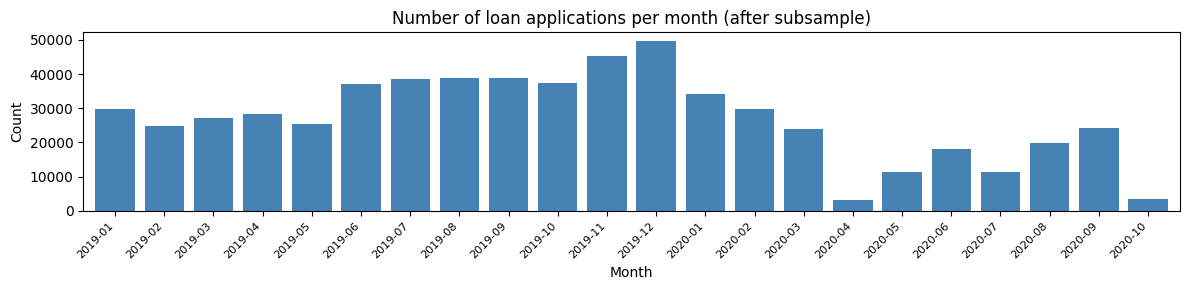

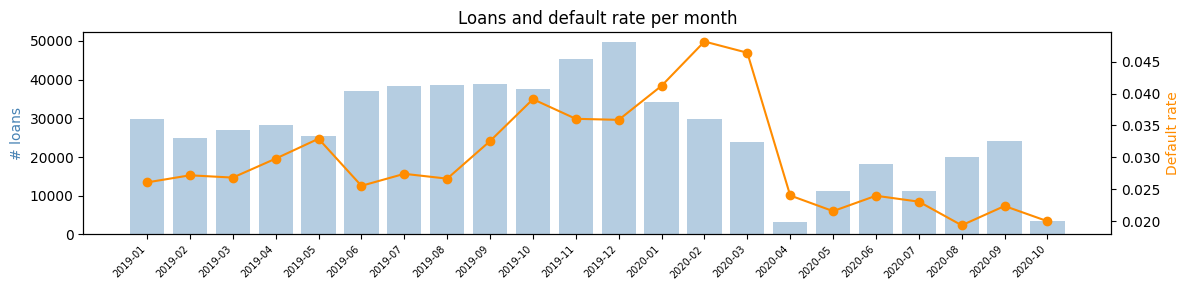

In [16]:
# Loans per month after subsampling.
fig, ax = plt.subplots(figsize=(12, 3))
meta_check['date_decision'].dt.to_period('M').astype(str).value_counts().sort_index().plot(
    ax=ax, kind='bar', width=0.8, color='steelblue')
ax.set_title('Number of loan applications per month (after subsample)')
ax.set_xlabel('Month'); ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(PROC_DIR / 'date_distribution.png', dpi=120)
plt.show()

# Default rate over time.
monthly = meta_check.copy()
monthly['target'] = Y_check
monthly_rate = monthly.groupby(monthly['date_decision'].dt.to_period('M'))['target'].agg(['mean', 'count'])
fig, ax = plt.subplots(figsize=(12, 3))
ax2 = ax.twinx()
ax.bar(range(len(monthly_rate)), monthly_rate['count'].values, color='steelblue', alpha=0.4)
ax2.plot(range(len(monthly_rate)), monthly_rate['mean'].values, marker='o', color='darkorange')
ax.set_xticks(range(len(monthly_rate)))
ax.set_xticklabels([str(p) for p in monthly_rate.index], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('# loans', color='steelblue')
ax2.set_ylabel('Default rate', color='darkorange')
ax.set_title('Loans and default rate per month')
plt.tight_layout(); plt.show()